# Probing AlphaEarth Embeddings for Urban Heat Analysis in Philadelphia

**Group members:** Lauren Choi & Chloe Robinson  
**Submission date:** [Apr 25, 2026]

This project evaluates whether Google AlphaEarth satellite embeddings can predict urban land surface temperature (LST) better than standard hand-crafted remote sensing indices. Instead of creating a subjective heat vulnerability classification score, we frame the project as a cleaner machine learning probe: do learned geospatial embeddings contain thermal information beyond what NDVI, NDBI, and NDWI already capture?

The project compares two ridge regression models:

1. **Baseline model:** NDVI, NDBI, and NDWI → Landsat-derived LST  
2. **Primary model:** AlphaEarth embeddings → Landsat-derived LST  

The final outputs are model performance metrics, observed-versus-predicted plots, residual maps, and error analyses that show where the model performs well or poorly.

## Problem Definition and Technical Justification

Extreme heat is one of the most serious climate-related risks in cities. Urban heat is not distributed evenly: dense built environments, low vegetation cover, impervious surfaces, and limited shade can create much hotter surface conditions in some neighborhoods than others. For urban planners and public health practitioners, understanding these spatial heat patterns is important for prioritizing tree planting, cooling infrastructure, shaded transit improvements, and emergency heat response.

The target user is an urban climate analyst, municipal planning agency, or public health organization interested in using remote sensing to understand spatial heat patterns. The specific output is not a final social vulnerability map, but a model-based analysis of whether foundation-model satellite embeddings contain useful information for predicting surface heat.

The model is learning a relationship between satellite-derived predictors and observed land surface temperature. The baseline model learns from three interpretable indices: NDVI for vegetation, NDBI for built-up intensity, and NDWI for moisture/water-related conditions. The primary model learns from 64-dimensional AlphaEarth embeddings, which are learned representations of surface conditions. By comparing these two models, we test whether learned embeddings add value beyond traditional remote sensing features.

We anticipated several failure modes. First, the embeddings may contain thermal information from pretraining inputs, which creates a possible leakage concern. Second, a random pixel split may overstate model performance because nearby pixels are spatially autocorrelated. Third, LST from a single Landsat scene captures surface temperature at one moment, not full human heat exposure or experienced vulnerability. Finally, even if embeddings predict LST well, they may be less interpretable than simpler indices. These limitations are revisited in the evaluation and discussion sections.

In [67]:
# Import and Setup

In [2]:
import os
import asyncio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import dask.array as da
import xarray as xr

from pystac_client import Client as STACClient
from dask.distributed import Client as DaskClient
import planetary_computer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error

from aef_loader import AEFIndex, VirtualTiffReader, DataSource
from aef_loader.utils import dequantize_aef, reproject_datatree
from odc.geo.geobox import GeoBox
from pyproj import Transformer

os.makedirs("data", exist_ok=True)

In [3]:
# Create Output Folder

In [4]:
os.makedirs("data", exist_ok=True)
print("Created data folder")

Created data folder


In [5]:
# Search Data STAC

In [6]:
catalog = STACClient.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

search = catalog.search(
    collections=["landsat-c2-l2"],
    bbox=[-75.3, 39.8, -74.9, 40.1],
    datetime="2024-06-01/2024-08-31",
    query={"eo:cloud_cover": {"lt": 20}},
)

items = list(search.items())
print(f"Found {len(items)} scenes")

items_sorted = sorted(items, key=lambda x: x.properties["eo:cloud_cover"])
item = items_sorted[0]

print("Selected item:", item.id)
print("Cloud cover:", item.properties["eo:cloud_cover"])

Found 3 scenes
Selected item: LC09_L2SP_014032_20240810_02_T1
Cloud cover: 7.56


In [7]:
# Load Bands

In [8]:
import rasterio
import numpy as np

# Band URLs
red_url = item.assets["red"].href
nir_url = item.assets["nir08"].href
swir_url = item.assets["swir16"].href
green_url = item.assets["green"].href
thermal_url = item.assets["lwir11"].href

# RED
with rasterio.open(red_url) as src:
    red_raw = src.read(1).astype("float32")
    red_transform = src.transform
    red_crs = src.crs
    profile = src.profile.copy()

# NIR
with rasterio.open(nir_url) as src:
    nir_raw = src.read(1).astype("float32")
    nir_transform = src.transform
    nir_crs = src.crs

# SWIR
with rasterio.open(swir_url) as src:
    swir_raw = src.read(1).astype("float32")
    swir_transform = src.transform
    swir_crs = src.crs

# GREEN
with rasterio.open(green_url) as src:
    green_raw = src.read(1).astype("float32")
    green_transform = src.transform
    green_crs = src.crs

# THERMAL
with rasterio.open(thermal_url) as src:
    thermal_raw = src.read(1).astype("float32")
    thermal_transform = src.transform
    thermal_crs = src.crs

# Mask invalid values
red_raw[red_raw <= 0] = np.nan
nir_raw[nir_raw <= 0] = np.nan
swir_raw[swir_raw <= 0] = np.nan
green_raw[green_raw <= 0] = np.nan
thermal_raw[thermal_raw <= 0] = np.nan

print("Loaded raw Landsat bands")
print("Red:", red_raw.shape)
print("NIR:", nir_raw.shape)
print("SWIR:", swir_raw.shape)
print("Green:", green_raw.shape)
print("Thermal:", thermal_raw.shape)

Loaded raw Landsat bands
Red: (7851, 7741)
NIR: (7851, 7741)
SWIR: (7851, 7741)
Green: (7851, 7741)
Thermal: (7851, 7741)


## Load AlphaEarth Embeddings

## Methodological Precedent

This project builds on three strands of prior work: Landsat-based urban heat analysis, index-based remote sensing of urban form, and foundation-model embeddings for Earth observation.

First, Landsat thermal imagery is widely used to estimate land surface temperature and identify urban heat patterns. Prior urban heat island studies show that LST is strongly related to land cover, vegetation abundance, and built surface conditions. This supports our use of Landsat-derived LST as the target variable for the model.

Second, vegetation and built-environment indices are common explanatory variables in urban heat studies. NDVI is often used as a proxy for vegetation and cooling potential, while NDBI captures built-up intensity and NDWI helps identify moisture or water-related conditions. These indices form a transparent baseline because they are simple, interpretable, and directly connected to known drivers of urban heat.

Third, AlphaEarth embeddings represent a newer foundation-model approach to remote sensing. Instead of relying only on hand-designed indices, AlphaEarth provides a high-dimensional learned representation of surface conditions. This project uses a linear probe, ridge regression, to test whether those learned features encode thermal structure that is not fully captured by NDVI, NDBI, and NDWI.

**Sources informing this approach:** Weng et al. (2004) on Landsat LST and vegetation-temperature relationships; Voogt and Oke (2003) on thermal remote sensing of urban climates; Google/AlphaEarth documentation on Satellite Embedding V1; and the class AlphaEarth tutorial.

In [9]:
# Using tutorial from class (https://www.geopythontutorials.com/notebooks/xarray_embeddings_similarity_search.html)

In [ ]:
# Set up a Dask Cluster
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 5
Total threads: 10,Total memory: 24.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:62338,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:62353,Total threads: 2
Dashboard: http://127.0.0.1:62364/status,Memory: 4.80 GiB
Nanny: tcp://127.0.0.1:62341,


In [11]:
# Define search region
bbox = [-75.3, 39.8, -74.9, 40.1]
target_crs = 'EPSG:3857'
year = 2024

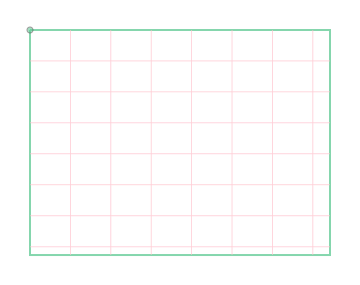

In [12]:
# Transform bbox from EPSG:4326 to chosen crs
transformer = Transformer.from_crs('EPSG:4326', target_crs, always_xy=True)
x_min, y_min = transformer.transform(bbox[0], bbox[1])
x_max, y_max = transformer.transform(bbox[2], bbox[3])

geobox = GeoBox.from_bbox(
    bbox=(x_min, y_min, x_max, y_max),
    crs=target_crs,
    resolution=30,
)

geobox

In [13]:
# Load the embeddings
index = AEFIndex(source=DataSource.SOURCE_COOP)
await index.download()

# Query for tiles
tiles = await index.query(
    bbox=bbox,
    years=(year),
)

# Load tiles organized by UTM zone
async with VirtualTiffReader() as reader:
    tree = await reader.open_tiles_by_zone(tiles)

# Depending on the region, there maybe multiple
# tiles spanning different UTM zones
# Reproject all the tiles to the target GeoBox
# with the chosen projection and pixel resolution
combined = reproject_datatree(tree, target_geobox=geobox)
embeddings = combined.embeddings
embeddings

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/virtual_tiff/parser.py:210: UserWarning: Imagecodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  return ZstdCodec(level=ifd.other_tags.get(ZSTD_LEVEL_TAG, DEFAULT_ZSTD_LEVEL))
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/virtual_tiff/imagecodecs.py:77: UserWarning: Imagecodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  return cls(**data.get("configuration", {}))
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/virtual_tiff/parser.py:210: UserWarning: Imagecodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  return ZstdCodec(level=ifd.other_tags.get(ZSTD_LEVEL_TAG, DEFAULT_ZSTD_LEVEL))
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/si

<xarray.DataArray 'embeddings' (time: 1, band: 64, y: 1453, x: 1485)> Size: 552MB
dask.array<reproject, shape=(1, 64, 1453, 1485), dtype=float32, chunksize=(1, 1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[us] 8B 2024-01-01
  * band         (band) <U3 768B 'A00' 'A01' 'A02' 'A03' ... 'A61' 'A62' 'A63'
  * y            (y) float64 12kB 4.88e+06 4.88e+06 ... 4.837e+06 4.837e+06
  * x            (x) float64 12kB -8.382e+06 -8.382e+06 ... -8.338e+06
    spatial_ref  int32 4B 3857
Attributes:
    citation:                    True
    geog_angular_units:          True
    geog_citation:               True
    model_type:                  True
    proj_linear_units:           True
    projected_type:              True
    raster_type:                 True
    photometric_interpretation:  1
    DESCRIPTION:                 A63
    gdal_no_data:                -128
    nodata:                      -128
    _FillValue:                  -128

In [14]:
# Dequantise the embeddings
# the embeddings are saved as 8-bit integers so we need to convert them back to float values
embeddings_year = embeddings.isel(time=0)
embeddings_float = dequantize_aef(embeddings_year)
embeddings_float

<xarray.DataArray 'embeddings' (band: 64, y: 1453, x: 1485)> Size: 552MB
dask.array<where, shape=(64, 1453, 1485), dtype=float32, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) <U3 768B 'A00' 'A01' 'A02' 'A03' ... 'A61' 'A62' 'A63'
  * y            (y) float64 12kB 4.88e+06 4.88e+06 ... 4.837e+06 4.837e+06
  * x            (x) float64 12kB -8.382e+06 -8.382e+06 ... -8.338e+06
    time         datetime64[us] 8B 2024-01-01
    spatial_ref  int32 4B 3857
Attributes: (12/14)
    citation:                    True
    geog_angular_units:          True
    geog_citation:               True
    model_type:                  True
    proj_linear_units:           True
    projected_type:              True
    ...                          ...
    DESCRIPTION:                 A63
    gdal_no_data:                -128
    nodata:                      nan
    _FillValue:                  nan
    units:                       embedding
    dequantized:                 True

In [15]:
# Convert embeddings to NumPY array
# Get embeddings as dask array: (bands, y, x)
emb = embeddings_float.data

# Transpose to (y, x, bands)
emb = da.moveaxis(emb, 0, -1)  # (y, x, bands)

embeddings_np = emb.compute()

print("Embeddings shape:", embeddings_np.shape)

Embeddings shape: (1453, 1485, 64)


In [16]:
# Flatten embeddings into a 2D array for regression
X_embed = embeddings_np.reshape(-1, embeddings_np.shape[-1])

print("Embedding feature matrix shape:", X_embed.shape)

Embedding feature matrix shape: (2157705, 64)


## Construct Aligned Dataset for Modeling 

## Data and Preprocessing

The study area is Philadelphia, Pennsylvania, using a bounding box around the city. The target variable is Landsat-derived land surface temperature from a low-cloud Landsat scene selected through the Planetary Computer STAC catalog. The selected scene was `LC09_L2SP_014032_20240810_02_T1`, with reported cloud cover of 7.56%. The Landsat bands used in this analysis include red, near-infrared, shortwave infrared, green, and thermal bands.

The baseline predictors are three hand-crafted indices: NDVI, NDBI, and NDWI. NDVI captures vegetation greenness, NDBI captures built-up intensity, and NDWI captures water or moisture-related surface conditions. These variables are useful because they are interpretable and directly connected to urban heat processes.

The primary predictors are 64 AlphaEarth embedding dimensions. The embeddings were loaded for 2024 and aligned to the same spatial grid as the Landsat variables. Because the embeddings and Landsat imagery originally come from different sources and resolutions, the Landsat bands were reprojected to the shared GeoBox grid used by the embeddings. This ensured that each model observation had baseline features, embedding features, and an LST target on the same aligned raster grid.

Invalid values were removed before modeling. The final valid grid contained 2,157,705 pixels, and a random subsample of 200,000 pixels was used for model training and testing to reduce computational cost. The sample was split into 160,000 training pixels and 40,000 testing pixels. This enabled fast model fitting while still retaining a large number of observations.

### Baseline Dataset (NDVI, NDBI, NDWI → LST)

In [17]:
from rasterio.warp import reproject, Resampling

def reproject_to_geobox(src_array, src_transform, src_crs, geobox, resampling=Resampling.bilinear):
    dst_array = np.full((geobox.shape.y, geobox.shape.x), np.nan, dtype="float32")

    reproject(
        source=src_array,
        destination=dst_array,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=geobox.transform,
        dst_crs=str(geobox.crs),
        resampling=resampling,
        dst_nodata=np.nan,
    )
    return dst_array

In [18]:
# Reproject Landsat bands to the shared GeoBox grid

red = reproject_to_geobox(red_raw, red_transform, red_crs, geobox)
nir = reproject_to_geobox(nir_raw, nir_transform, nir_crs, geobox)
swir = reproject_to_geobox(swir_raw, swir_transform, swir_crs, geobox)
green = reproject_to_geobox(green_raw, green_transform, green_crs, geobox)
thermal = reproject_to_geobox(thermal_raw, thermal_transform, thermal_crs, geobox)

print("Aligned Landsat shape:", red.shape)
print("Aligned embedding shape:", embeddings_np.shape[:2])

Aligned Landsat shape: (1453, 1485)
Aligned embedding shape: (1453, 1485)


In [19]:
# Compute NDVI, NDBI, and NDWI on aligned grid

ndvi = (nir - red) / (nir + red)
ndbi = (swir - nir) / (swir + nir)
ndwi = (green - nir) / (green + nir)

print("NDVI:", np.nanmin(ndvi), "to", np.nanmax(ndvi))
print("NDBI:", np.nanmin(ndbi), "to", np.nanmax(ndbi))
print("NDWI:", np.nanmin(ndwi), "to", np.nanmax(ndwi))

NDVI: -0.14956471 to 0.5604212
NDBI: -0.42162815 to 0.34979323
NDWI: -0.5379978 to 0.20641297


In [20]:
# Convert thermal band to Land Surface Temperature (LST)

lst = thermal * 0.00341802 + 149.0

print("LST stats (Kelvin):")
print("Min:", np.nanmin(lst))
print("Max:", np.nanmax(lst))

LST stats (Kelvin):
Min: 287.84302
Max: 334.58557


In [21]:
# Build baseline feature matrix and target shape

X_baseline = np.stack([ndvi, ndbi, ndwi], axis=-1).reshape(-1, 3)
y = lst.reshape(-1)

valid_mask = (~np.isnan(X_baseline).any(axis=1)) & (~np.isnan(y))

X_baseline = X_baseline[valid_mask]
y = y[valid_mask]

print("Baseline feature matrix shape:", X_baseline.shape)
print("Target shape:", y.shape)

Baseline feature matrix shape: (2157705, 3)
Target shape: (2157705,)


### Embedding Dataset (AlphaEarth -> LST)

In [22]:
# Apply same valid pixel mask to embeddings

X_embed = X_embed[valid_mask]

print("Embedding feature matrix shape:", X_embed.shape)

Embedding feature matrix shape: (2157705, 64)


## Exploratory Map Visualizations

Before building the modeling dataset, we visualize the aligned raster layers used in the analysis. These maps help show the spatial patterns in vegetation, built-up intensity, moisture, and land surface temperature across the study area.

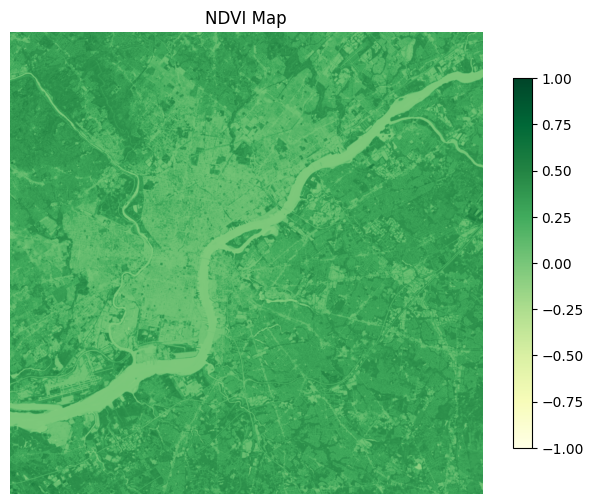

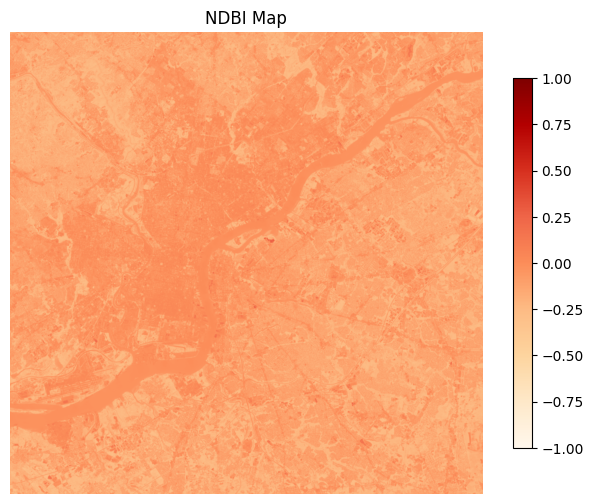

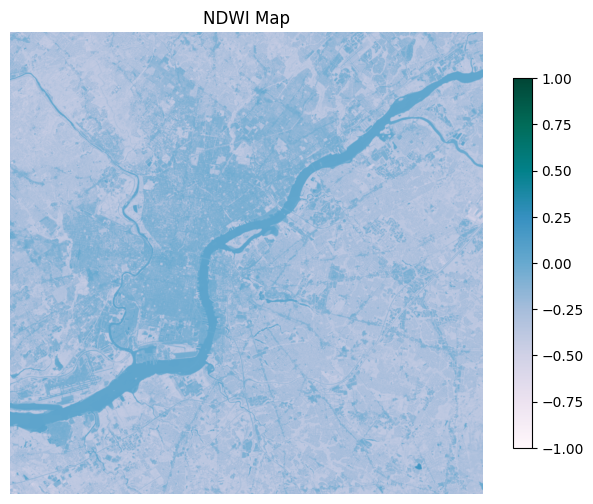

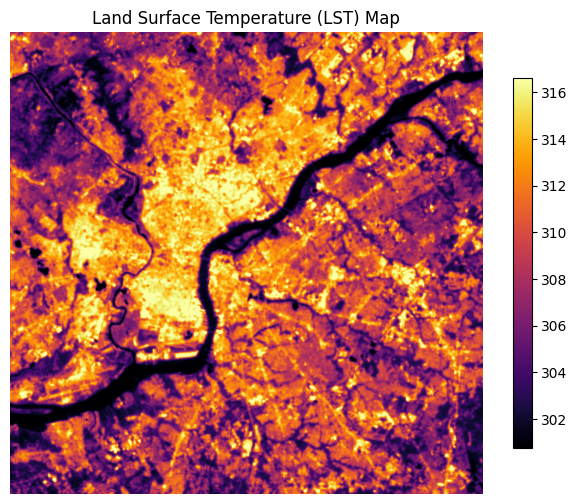

In [44]:
import matplotlib.pyplot as plt
import numpy as np

def plot_raster(arr, title, cmap="viridis", center_zero=False, vmin=None, vmax=None):
    plt.figure(figsize=(8, 6))

    masked = np.ma.masked_invalid(arr)

    if center_zero:
        if vmin is None or vmax is None:
            vmax = np.nanpercentile(np.abs(arr), 98)
            vmin = -vmax
    else:
        if vmin is None:
            vmin = np.nanpercentile(arr, 2)
        if vmax is None:
            vmax = np.nanpercentile(arr, 98)

    im = plt.imshow(masked, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.axis("off")
    plt.colorbar(im, shrink=0.8)
    plt.show()

# NDVI
plot_raster(
    ndvi,
    "NDVI Map",
    cmap="YlGn",
    vmin=-1,
    vmax=1
)

# NDBI
plot_raster(
    ndbi,
    "NDBI Map",
    cmap="OrRd",
    vmin=-1,
    vmax=1
)

# NDWI
plot_raster(
    ndwi,
    "NDWI Map",
    cmap="PuBuGn",
    vmin=-1,
    vmax=1
)

# LST
plot_raster(
    lst,
    "Land Surface Temperature (LST) Map",
    cmap="inferno"
)

### Exploratory Map Interpretation

The exploratory maps show that the input variables capture meaningful spatial differences across the Philadelphia study area. The NDVI map highlights greener areas with higher vegetation levels, while the NDBI map emphasizes more built-up surfaces. The NDWI map clearly distinguishes water and moisture-related surfaces, especially along major water bodies. The LST map shows the spatial structure of surface heat, with cooler areas generally corresponding to water or vegetation and hotter areas corresponding more closely to built-up or impervious surfaces.

These maps are important because they confirm that the baseline features are not abstract variables; they represent physical surface characteristics that are directly related to urban heat. They also help explain why a simple index-based baseline should perform reasonably well, even before introducing AlphaEarth embeddings.

In [23]:
# Subsample both datasets together

n_samples = 200000
rng = np.random.default_rng(42)

sample_idx = rng.choice(len(y), size=n_samples, replace=False)

X_baseline = X_baseline[sample_idx]
X_embed = X_embed[sample_idx]
y = y[sample_idx]

print("Subsampled baseline shape:", X_baseline.shape)
print("Subsampled embedding shape:", X_embed.shape)
print("Subsampled target shape:", y.shape)

Subsampled baseline shape: (200000, 3)
Subsampled embedding shape: (200000, 64)
Subsampled target shape: (200000,)


### Shared Train/Test Split

In [24]:
pixel_idx = np.arange(len(y))

train_idx, test_idx = train_test_split(
    pixel_idx,
    test_size=0.2,
    random_state=42
)

Xb_train = X_baseline[train_idx]
Xb_test = X_baseline[test_idx]

Xe_train = X_embed[train_idx]
Xe_test = X_embed[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

print("Baseline train:", Xb_train.shape)
print("Baseline test:", Xb_test.shape)
print("Embedding train:", Xe_train.shape)
print("Embedding test:", Xe_test.shape)

Baseline train: (160000, 3)
Baseline test: (40000, 3)
Embedding train: (160000, 64)
Embedding test: (40000, 64)


# Modeling and Evaluation

## Baseline Model

In [25]:
# Standardise the Features for Ridge Regression
baseline_scaler = StandardScaler()
Xb_train_scaled = baseline_scaler.fit_transform(Xb_train)
Xb_test_scaled = baseline_scaler.transform(Xb_test)

In [26]:
# Train baseline ridge regression model
ridge_baseline = Ridge(alpha=1.0)
ridge_baseline.fit(Xb_train_scaled, y_train)

y_pred_baseline = ridge_baseline.predict(Xb_test_scaled)

In [27]:
# Evaluate baseline model performance
baseline_r2 = r2_score(y_test, y_pred_baseline)
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)

print("Baseline Model: NDVI + NDBI + NDWI -> LST")
print("R²:", baseline_r2)
print("MAE:", baseline_mae)

Baseline Model: NDVI + NDBI + NDWI -> LST
R²: 0.5399819016456604
MAE: 2.1613452434539795


### Baseline Model Interpretation

The baseline model uses only NDVI, NDBI, and NDWI to predict Landsat-derived LST. This model is intentionally simple and interpretable. It establishes a performance floor for the project by asking how much of the LST pattern can be explained using standard remote sensing indices alone.

The baseline achieved an R² of approximately **0.54** and an MAE of approximately **2.16 K**. This means that the three indices explain a moderate share of LST variation, but they still leave substantial unexplained error. The result is reasonable because vegetation, built-up intensity, and water/moisture conditions are important drivers of urban surface temperature, but they do not fully capture material properties, spatial texture, temporal surface behavior, or other complex landscape characteristics.

In [28]:
# Inspect baseline model coefficients
coef_df = pd.DataFrame({
    "Feature": ["NDVI", "NDBI", "NDWI"],
    "Coefficient": ridge_baseline.coef_
})

coef_df

,Feature,Coefficient
0,NDVI,-16.396902
1,NDBI,3.100048
2,NDWI,-17.579075


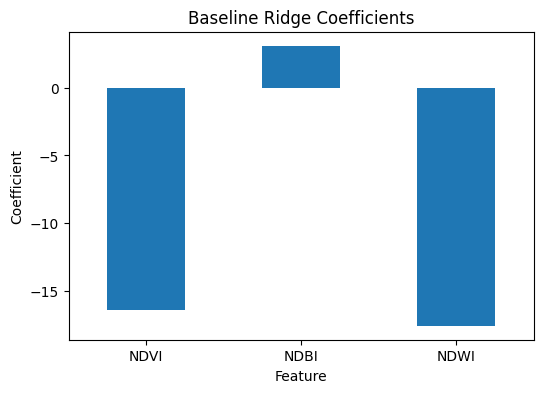

In [29]:
# Plot baseline model coefficients
coef_df.plot.bar(x="Feature", y="Coefficient", legend=False, figsize=(6, 4))
plt.title("Baseline Ridge Coefficients")
plt.ylabel("Coefficient")
plt.xticks(rotation=0)
plt.show()

### Baseline Coefficient Interpretation

The baseline coefficients provide a useful check on whether the model is learning relationships that make physical sense. NDVI and NDWI have negative coefficients, meaning that greener or more water/moisture-associated pixels are generally predicted to have lower LST. NDBI has a positive coefficient, meaning that more built-up pixels are generally predicted to be hotter.

This pattern is consistent with urban heat theory: vegetation and water tend to cool surfaces through shading, evapotranspiration, and thermal moderation, while built-up and impervious surfaces tend to retain and radiate more heat.

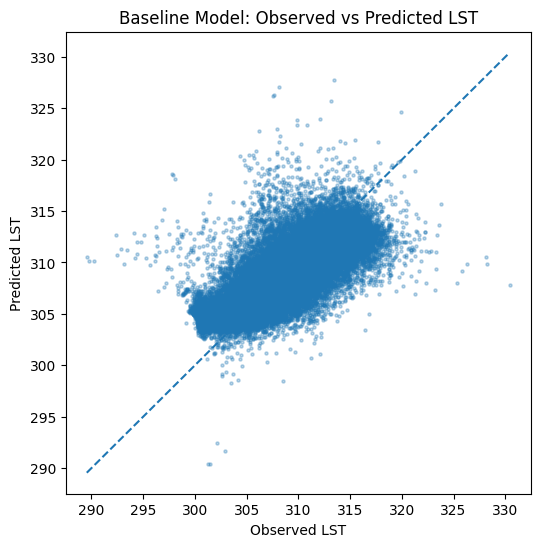

In [30]:
# Plot observed vs predicted LST for the baseline model

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_baseline, s=5, alpha=0.3)
plt.xlabel("Observed LST")
plt.ylabel("Predicted LST")
plt.title("Baseline Model: Observed vs Predicted LST")

min_val = min(y_test.min(), y_pred_baseline.min())
max_val = max(y_test.max(), y_pred_baseline.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.show()

## Embedding Model

In [31]:
# Standardize embedding features before ridge regression
embed_scaler = StandardScaler()
Xe_train_scaled = embed_scaler.fit_transform(Xe_train)
Xe_test_scaled = embed_scaler.transform(Xe_test)

In [32]:
# Train embedding ridge regression model
ridge_embed = Ridge(alpha=1.0)
ridge_embed.fit(Xe_train_scaled, y_train)

y_pred_embed = ridge_embed.predict(Xe_test_scaled)

In [33]:
# Evaluate embedding model performance
embed_r2 = r2_score(y_test, y_pred_embed)
embed_mae = mean_absolute_error(y_test, y_pred_embed)

print("Embedding Model: AlphaEarth Embeddings -> LST")
print("R²:", embed_r2)
print("MAE:", embed_mae)

Embedding Model: AlphaEarth Embeddings -> LST
R²: 0.8673392534255981
MAE: 1.040975570678711


### Primary Model Interpretation

The primary model uses the 64-dimensional AlphaEarth embeddings to predict Landsat-derived LST. This model is still a ridge regression rather than a complex deep learning model, but it uses a much richer input representation than the baseline. The goal is not to train a new foundation model, but to probe whether the existing embeddings contain information useful for predicting urban thermal patterns.

The embedding model achieved an R² of approximately **0.87** and an MAE of approximately **1.04 K**. This is a strong improvement over the index baseline. The result suggests that the AlphaEarth embeddings capture additional information related to surface heat that is not fully represented by NDVI, NDBI, and NDWI alone. This may include more complex spatial, spectral, and temporal patterns of land cover and surface conditions.

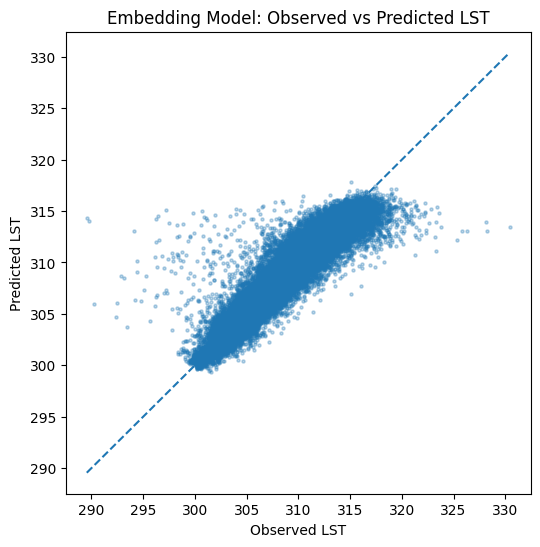

In [34]:
# Plot observed vs predicted LST for the embedding model

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_embed, s=5, alpha=0.3)
plt.xlabel("Observed LST")
plt.ylabel("Predicted LST")
plt.title("Embedding Model: Observed vs Predicted LST")

min_val = min(y_test.min(), y_pred_embed.min())
max_val = max(y_test.max(), y_pred_embed.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.show()

## Model Comparison

In [57]:
# Compare baseline and embedding models
# RMSE
baseline_rmse = mean_squared_error(y_test, y_pred_baseline) ** 0.5
embed_rmse = mean_squared_error(y_test, y_pred_embed) ** 0.5

# Comparison table
comparison_df = pd.DataFrame({
    "Model": ["Baseline: NDVI/NDBI/NDWI", "AlphaEarth Embeddings"],
    "R2": [baseline_r2, embed_r2],
    "MAE": [baseline_mae, embed_mae],
    "RMSE": [baseline_rmse, embed_rmse]
})

comparison_df

comparison_df

,Model,R2,MAE,RMSE
0,Baseline: NDVI/NDBI/NDWI,0.539982,2.161345,2.845191
1,AlphaEarth Embeddings,0.867339,1.040976,1.527901


In [60]:
r2_gain = embed_r2 - baseline_r2
mae_reduction = baseline_mae - embed_mae
mae_reduction_pct = (mae_reduction / baseline_mae) * 100

rmse_reduction = baseline_rmse - embed_rmse
rmse_reduction_pct = (rmse_reduction / baseline_rmse) * 100

print(f"R² gain from embeddings: {r2_gain:.3f}")
print(f"MAE reduction from embeddings: {mae_reduction:.3f} K ({mae_reduction_pct:.1f}%)")
print(f"RMSE reduction from embeddings: {rmse_reduction:.3f} K ({rmse_reduction_pct:.1f}%)")

R² gain from embeddings: 0.327
MAE reduction from embeddings: 1.120 K (51.8%)
RMSE reduction from embeddings: 1.317 K (46.3%)


In [58]:
baseline_r2
embed_r2
baseline_mae
embed_mae

1.040975570678711

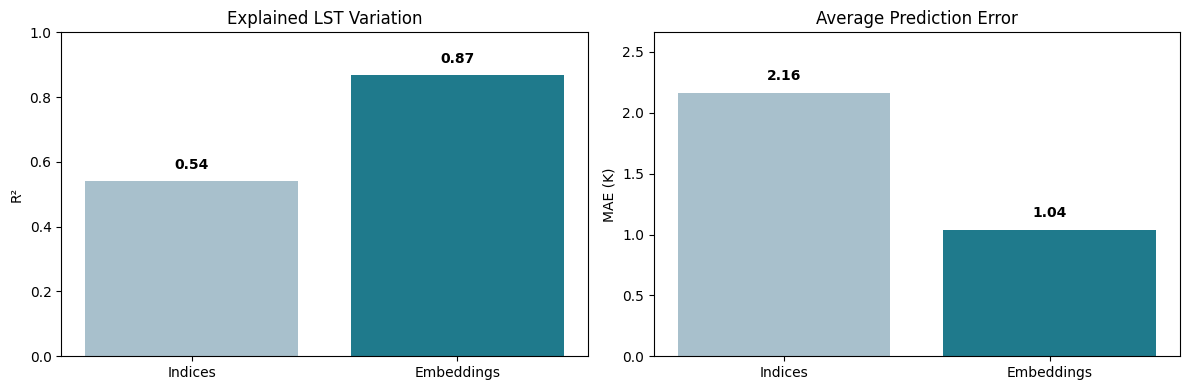

In [59]:
import matplotlib.pyplot as plt

models = ["Indices", "Embeddings"]
r2_values = [baseline_r2, embed_r2]
mae_values = [baseline_mae, embed_mae]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# R² chart
axes[0].bar(models, r2_values, color=["#A8C0CC", "#1F7A8C"])
axes[0].set_title("Explained LST Variation")
axes[0].set_ylabel("R²")
axes[0].set_ylim(0, 1)

for i, value in enumerate(r2_values):
    axes[0].text(i, value + 0.03, f"{value:.2f}", 
                 ha="center", va="bottom", fontweight="bold")

# MAE chart
axes[1].bar(models, mae_values, color=["#A8C0CC", "#1F7A8C"])
axes[1].set_title("Average Prediction Error")
axes[1].set_ylabel("MAE (K)")
axes[1].set_ylim(0, max(mae_values) + 0.5)

for i, value in enumerate(mae_values):
    axes[1].text(i, value + 0.08, f"{value:.2f}", 
                 ha="center", va="bottom", fontweight="bold")

plt.tight_layout()

# Save for presentation
plt.savefig("model_comparison_bar_charts.png", dpi=300, bbox_inches="tight")

plt.show()

## Model Comparison

The embedding model substantially outperformed the index-based baseline. The baseline model using NDVI, NDBI, and NDWI achieved an R² of **0.54**, MAE of **2.16 K**, and RMSE of **2.85 K**. The AlphaEarth embedding model achieved an R² of **0.87**, MAE of **1.04 K**, and RMSE of **1.53 K**.

This represents an R² gain of approximately **0.33**, a **51.8% reduction in MAE**, and a **46.3% reduction in RMSE**. In practical terms, the embedding model explains much more of the spatial variation in LST and makes substantially smaller prediction errors.

The added complexity appears worthwhile for this task because the embedding model produces a large improvement while still using a relatively simple ridge regression architecture. However, the improvement should be interpreted alongside the limitations discussed later, especially possible thermal leakage and the use of a random pixel split.

## Residual Analysis

In [45]:
# Compute residuals for the embedding model
residuals = y_test - y_pred_embed

In [61]:
# Residuals should be observed - predicted
baseline_residuals = y_test - y_pred_baseline
embed_residuals = y_test - y_pred_embed

residual_df = pd.DataFrame({
    "Observed_LST": y_test,
    "Baseline_Predicted": y_pred_baseline,
    "Embedding_Predicted": y_pred_embed,
    "Baseline_Residual": baseline_residuals,
    "Embedding_Residual": embed_residuals,
    "Baseline_Abs_Error": np.abs(baseline_residuals),
    "Embedding_Abs_Error": np.abs(embed_residuals)
})

residual_df.head()

,Observed_LST,Baseline_Predicted,Embedding_Predicted,Baseline_Residual,Embedding_Residual,Baseline_Abs_Error,Embedding_Abs_Error
0,309.895996,309.697266,308.804443,0.198730,1.091553,0.198730,1.091553
1,312.413330,310.464020,311.721588,1.949310,0.691742,1.949310,0.691742
2,315.374664,310.486725,313.448669,4.887939,1.925995,4.887939,1.925995
3,313.588470,312.308716,310.942108,1.279755,2.646362,1.279755,2.646362
4,294.201630,310.403931,306.345276,-16.202301,-12.143646,16.202301,12.143646


In [62]:
residual_df["LST_bin"] = pd.qcut(
    residual_df["Observed_LST"],
    q=5,
    labels=["Coolest", "Cool", "Middle", "Hot", "Hottest"]
)

error_by_temp = residual_df.groupby("LST_bin")[[
    "Baseline_Abs_Error",
    "Embedding_Abs_Error"
]].mean()

error_by_temp

,Baseline_Abs_Error,Embedding_Abs_Error
LST_bin,,
Coolest,2.768904,1.000053
Cool,1.737519,0.982273
Middle,1.642858,0.966691
Hot,1.849583,0.962763
Hottest,2.807862,1.293098


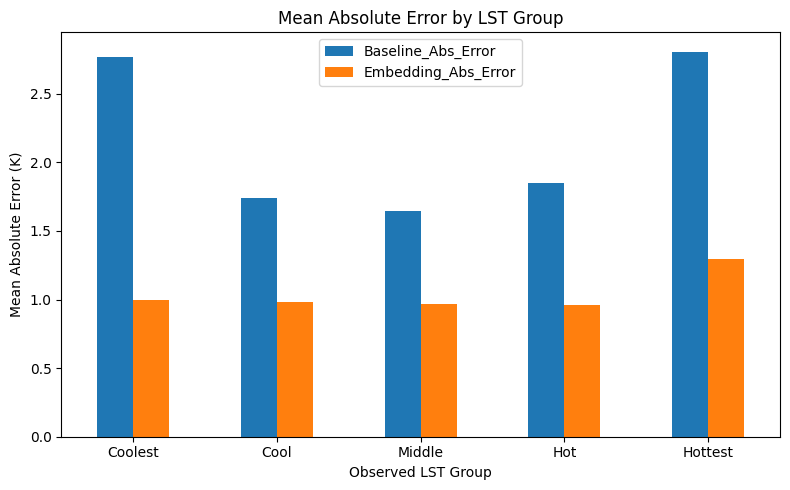

In [63]:
error_by_temp.plot(kind="bar", figsize=(8, 5))

plt.title("Mean Absolute Error by LST Group")
plt.ylabel("Mean Absolute Error (K)")
plt.xlabel("Observed LST Group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Error by Temperature Group

The error-by-temperature analysis shows whether the models perform equally well across cool, moderate, and hot areas. This matters because an urban heat model is most useful when it performs well in the hottest locations, not only in average conditions.

The embedding model outperformed the baseline across all LST groups. For the coolest pixels, the baseline mean absolute error was about **2.77 K**, compared with **1.00 K** for the embedding model. For the hottest pixels, the baseline error was about **2.81 K**, compared with **1.29 K** for the embedding model. This suggests that the embeddings improve performance at both ends of the temperature distribution.

However, the embedding model still performs worst in the hottest LST group, where its average absolute error rises to approximately **1.29 K**. This suggests that extremely hot surfaces remain harder to predict, even with the richer embedding representation.

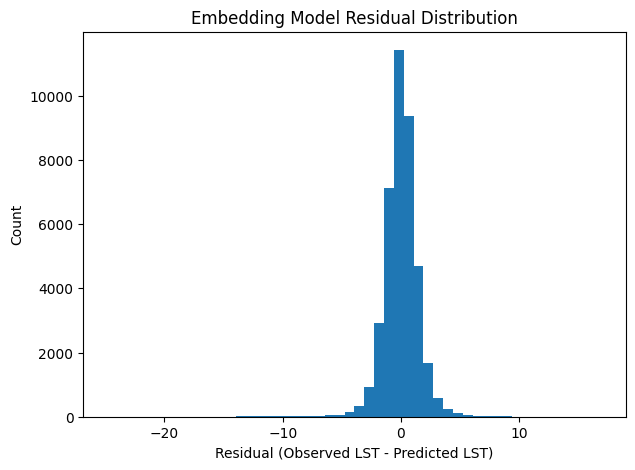

In [68]:
# Plot distribution of embedding-model residuals
plt.figure(figsize=(7, 5))
plt.hist(residuals, bins=50)
plt.xlabel("Residual (Observed LST - Predicted LST)")
plt.ylabel("Count")
plt.title("Embedding Model Residual Distribution")
plt.show()

### Residual Distribution Interpretation

The residual histogram shows the distribution of embedding-model errors. Residuals are calculated as observed LST minus predicted LST. Therefore, positive residuals mean the model underpredicted heat, while negative residuals mean the model overpredicted heat.

The residual distribution is centered close to zero, which suggests that the embedding model does not have a large overall directional bias. However, the remaining spread shows that some locations are still meaningfully over- or underpredicted. These errors are important because the most useful urban heat model is not only one that performs well on average, but also one that avoids missing unusually hot areas.

In [47]:
# Rebuild full-grid feature matrices (not just sampled pixels)
X_baseline_full = np.stack([ndvi, ndbi, ndwi], axis=-1).reshape(-1, 3)
X_embed_full = embeddings_np.reshape(-1, embeddings_np.shape[-1])
y_full = lst.reshape(-1)

valid_mask_full = (
    (~np.isnan(X_baseline_full).any(axis=1)) &
    (~np.isnan(X_embed_full).any(axis=1)) &
    (~np.isnan(y_full))
)

print("Full valid pixels:", valid_mask_full.sum())

Full valid pixels: 2157705


In [48]:
# Predict on all valid pixels using the fitted models
baseline_pred_full = np.full(y_full.shape, np.nan, dtype="float32")
embed_pred_full = np.full(y_full.shape, np.nan, dtype="float32")

baseline_pred_full[valid_mask_full] = ridge_baseline.predict(
    baseline_scaler.transform(X_baseline_full[valid_mask_full])
)

embed_pred_full[valid_mask_full] = ridge_embed.predict(
    embed_scaler.transform(X_embed_full[valid_mask_full])
)

# Reshape back to raster grids
baseline_pred_grid = baseline_pred_full.reshape(lst.shape)
embed_pred_grid = embed_pred_full.reshape(lst.shape)

# Residuals: observed - predicted
baseline_resid_grid = lst - baseline_pred_grid
embed_resid_grid = lst - embed_pred_grid

In [49]:
import matplotlib.pyplot as plt
import numpy as np

def plot_raster(arr, title, cmap="viridis", center_zero=False, vmin=None, vmax=None):
    plt.figure(figsize=(8, 6))

    masked = np.ma.masked_invalid(arr)

    if center_zero:
        if vmin is None or vmax is None:
            vmax = np.nanpercentile(np.abs(arr), 98)
            vmin = -vmax

    elif vmin is None or vmax is None:
        vmin = np.nanpercentile(arr, 2)
        vmax = np.nanpercentile(arr, 98)

    im = plt.imshow(masked, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.axis("off")
    plt.colorbar(im, shrink=0.8)
    plt.show()

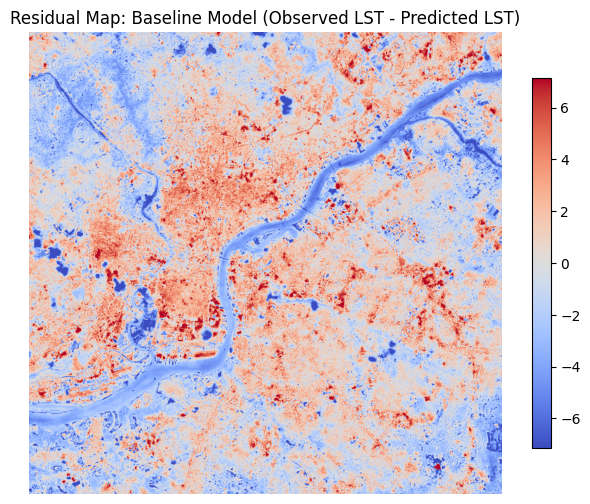

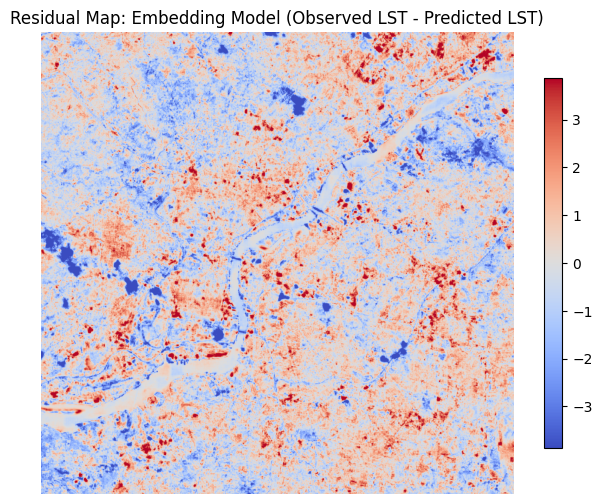

In [50]:
# Baseline residual map
plot_raster(
    baseline_resid_grid,
    "Residual Map: Baseline Model (Observed LST - Predicted LST)",
    cmap="coolwarm",
    center_zero=True
)

# Embedding residual map
plot_raster(
    embed_resid_grid,
    "Residual Map: Embedding Model (Observed LST - Predicted LST)",
    cmap="coolwarm",
    center_zero=True
)

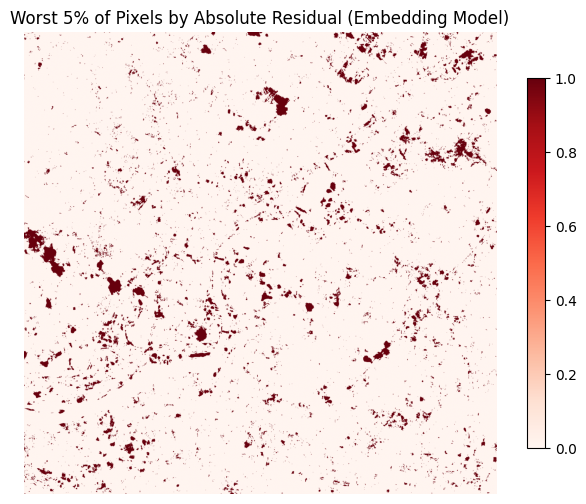

In [51]:
# Absolute residuals
embed_abs_resid = np.abs(embed_resid_grid)

# Top 5% worst-predicted pixels
threshold = np.nanpercentile(embed_abs_resid, 95)
poor_perf_mask = embed_abs_resid >= threshold

plot_raster(
    poor_perf_mask.astype(float),
    "Worst 5% of Pixels by Absolute Residual (Embedding Model)",
    cmap="Reds",
    vmin=0,
    vmax=1
)

### Spatial Residual Interpretation

The residual maps show where each model systematically over- or underpredicts land surface temperature across the full raster grid, not just the test sample. Because residuals are calculated as observed LST minus predicted LST, positive residuals indicate places that are hotter than the model predicted, while negative residuals indicate places that are cooler than the model predicted.

The baseline residual map shows larger and more spatially extensive errors, which is consistent with its lower R² and higher MAE. The embedding residual map appears less extreme and more spatially constrained, suggesting that the embeddings capture more of the spatial structure of LST than the three-index baseline.

The worst-performing pixels are identified using the top 5% of absolute residuals from the embedding model. These areas are especially useful for interpretation because they show where heat diverges most from what the model expects. Large positive residuals may represent places where actual heat is higher than surface appearance suggests, potentially due to impervious materials, industrial activity, transportation infrastructure, or anthropogenic heat. Large negative residuals may represent areas that visually appear heat-prone but are cooler in practice, possibly because of vegetation, water influence, or local microclimate.

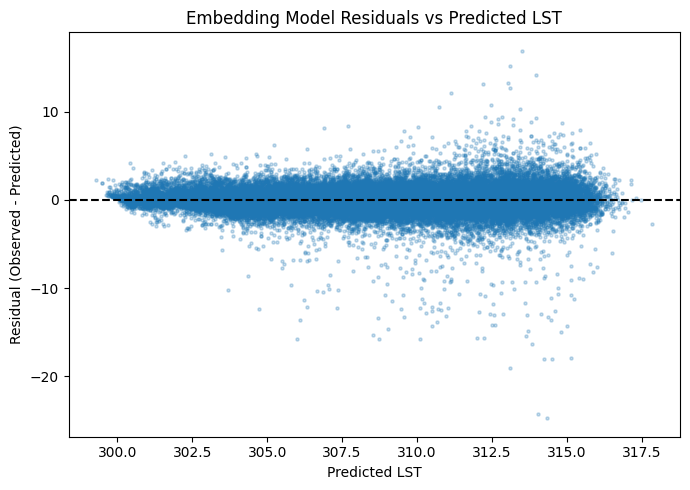

In [64]:
plt.figure(figsize=(7, 5))

plt.scatter(y_pred_embed, embed_residuals, alpha=0.25, s=5)
plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Predicted LST")
plt.ylabel("Residual (Observed - Predicted)")
plt.title("Embedding Model Residuals vs Predicted LST")

plt.tight_layout()
plt.show()

### Residual Bias Check

The residual-versus-predicted plot helps evaluate whether model errors are randomly distributed or systematically related to predicted temperature. Ideally, residuals should be scattered around zero with no strong pattern. If residuals increase or decrease with predicted LST, that would suggest the model is biased for certain temperature ranges.

In this model, residuals are generally centered near zero, but there is still visible spread, especially at higher predicted temperatures. This suggests that the embedding model performs well overall but still has difficulty capturing some extreme or locally unusual heat conditions.

In [52]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline (Indices)", "Embeddings"],
    "R2": [baseline_r2, embed_r2],
    "MAE": [baseline_mae, embed_mae]
})

comparison_df["R2_gain_vs_baseline"] = comparison_df["R2"] - baseline_r2
comparison_df["MAE_reduction_vs_baseline"] = baseline_mae - comparison_df["MAE"]

comparison_df

,Model,R2,MAE,R2_gain_vs_baseline,MAE_reduction_vs_baseline
0,Baseline (Indices),0.539982,2.161345,0.000000,0.00000
1,Embeddings,0.867339,1.040976,0.327357,1.12037


## Add Error by Landscape Type

In [65]:
# Get test-set baseline features
test_features_df = pd.DataFrame(Xb_test, columns=["NDVI", "NDBI", "NDWI"])

test_features_df["Observed_LST"] = y_test
test_features_df["Embedding_Residual"] = embed_residuals
test_features_df["Embedding_Abs_Error"] = np.abs(embed_residuals)

def classify_landscape(row):
    if row["NDWI"] > 0.2:
        return "Water-like"
    elif row["NDVI"] > 0.4:
        return "Vegetated"
    elif row["NDBI"] > 0.1:
        return "Built-up"
    else:
        return "Mixed/Other"

test_features_df["Landscape_Type"] = test_features_df.apply(classify_landscape, axis=1)

error_by_landscape = test_features_df.groupby("Landscape_Type").agg(
    mean_lst=("Observed_LST", "mean"),
    mean_residual=("Embedding_Residual", "mean"),
    mean_abs_error=("Embedding_Abs_Error", "mean"),
    count=("Observed_LST", "count")
).reset_index()

error_by_landscape

,Landscape_Type,mean_lst,mean_residual,mean_abs_error,count
0,Built-up,312.272064,0.149102,2.834264,69
1,Mixed/Other,309.422546,0.027424,1.059935,35715
2,Vegetated,304.649414,-0.210099,0.851014,4216


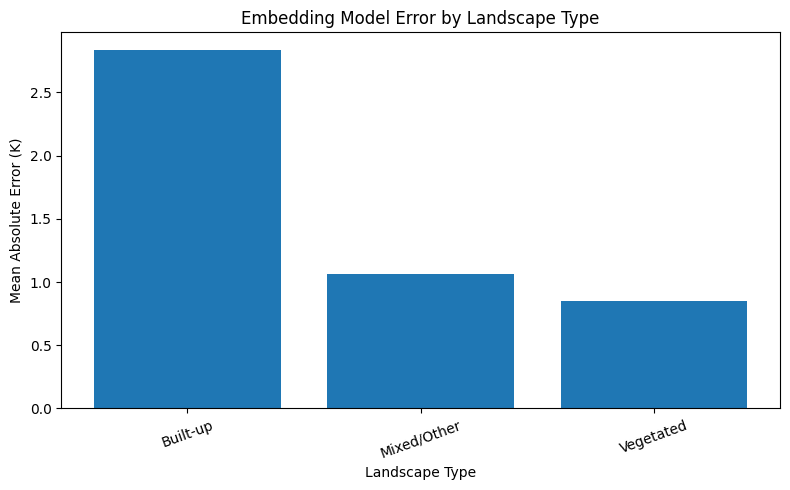

In [66]:
plt.figure(figsize=(8, 5))
plt.bar(error_by_landscape["Landscape_Type"], error_by_landscape["mean_abs_error"])

plt.title("Embedding Model Error by Landscape Type")
plt.ylabel("Mean Absolute Error (K)")
plt.xlabel("Landscape Type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Error by Landscape Type

The landscape-type analysis groups test pixels into approximate surface categories using NDVI, NDBI, and NDWI thresholds. This helps identify whether the embedding model performs differently across built-up, vegetated, and mixed areas.

The embedding model has the lowest mean absolute error in vegetated areas, at approximately **0.85 K**, and slightly higher error in mixed/other areas, at approximately **1.06 K**. The built-up category has a much higher mean absolute error of approximately **2.83 K**, but this result should be interpreted carefully because only **69** test pixels fall into that category based on the current threshold definition.

The higher error in built-up pixels suggests that dense urban surfaces may be more difficult to model. These areas can have complex heat behavior due to surface materials, shadows, roofs, roads, industrial land uses, and anthropogenic heat. This supports the idea that residual analysis is useful not only for measuring model accuracy, but also for identifying urban contexts where heat is harder to explain.

## Evaluation and Analysis Summary

Overall, the evaluation shows that AlphaEarth embeddings add substantial predictive value for LST estimation in this study area. The embedding model outperformed the NDVI/NDBI/NDWI baseline across all major metrics: R², MAE, and RMSE. The improvement is large enough to suggest that the embeddings contain thermal-relevant information not fully captured by the three hand-crafted indices.

Beyond the aggregate metrics, the residual analyses show what the model gets right and wrong. The embedding model reduces error across cool, moderate, and hot pixels, but the hottest group still has the largest error among embedding predictions. Spatial residual maps show that errors are geographically patterned rather than completely random, which suggests that some urban contexts remain harder to model. The landscape-type analysis further suggests that built-up areas may be more challenging, although the small number of built-up test pixels means this finding should be interpreted cautiously.

The model’s main success is its strong predictive performance using a simple ridge regression on learned embeddings. Its main limitation is interpretability. NDVI, NDBI, and NDWI are easier to explain physically, while embedding dimensions are less transparent. The model also relies on one Landsat scene and one city, so the results may not generalize across seasons, years, or different urban regions. Finally, possible thermal leakage in the AlphaEarth embeddings means that strong performance should be interpreted as evidence that the embeddings encode thermal structure, not necessarily that they infer heat from non-thermal features alone.

## Thermal Leakage Check

A key limitation of this project is possible thermal leakage. Google’s Satellite Embedding V1 documentation describes the embeddings as learned representations of surface conditions from multiple Earth observation signals, and the product is associated with Landsat-derived and Sentinel-1-derived inputs. In addition, the AlphaEarth Foundations description indicates that Landsat imagery includes thermal bands, which means thermal information may have been part of the broader foundation-model training pipeline.

This matters because the primary model is trying to predict Landsat-derived LST. If the AlphaEarth embeddings already encode thermal information from their pretraining inputs, then the strong performance of the embedding model may partly reflect thermal information already present in the representation. In that case, the project should be interpreted as a probe of whether AlphaEarth embeddings contain thermal structure, rather than as proof that the model infers heat independently from only non-thermal surface appearance. :contentReference[oaicite:2]{index=2}

## Future Work

With more time, the first improvement would be to use a spatially informed train/test split instead of a random pixel split. Random pixel splits can inflate model performance because nearby pixels often share similar land cover and temperature conditions. A block-based spatial split would provide a more rigorous test of whether the model generalizes to unseen parts of the city.

Second, this analysis should be repeated across multiple dates and seasons. A single Landsat scene captures surface temperature at one point in time, but urban heat risk changes across weather conditions, time of day, and season. Using multiple summer scenes or multi-year composites would make the results more stable and operationally useful.

Third, future work should test the model in other cities. Philadelphia has its own urban form, vegetation patterns, and material conditions, so the relationship between embeddings and LST may differ elsewhere. A multi-city evaluation would help determine whether AlphaEarth embeddings generalize across different urban environments.

Fourth, the thermal leakage issue should be investigated more directly. If an embedding product trained without thermal inputs is available, it could be compared against AlphaEarth embeddings to isolate whether the model is learning from non-thermal surface patterns or from thermal information already present in the representation.

Finally, the outputs could be connected back to planning practice by overlaying residual hotspots or predicted high-LST areas with demographic vulnerability, tree canopy, transit stops, cooling centers, or land use data. This would move the project from a model-probing exercise toward a more operational urban heat planning tool.

## Final Discussion and Conclusion

This project askes whether AlphaEarth embeddings add value beyond standard spectral indices for urban heat analysis. Based on the model results, the answer is yes: the embedding model substantially outperformed the NDVI/NDBI/NDWI baseline, increasing R² from approximately **0.54** to **0.87** and reducing MAE from approximately **2.16 K** to **1.04 K**.

This suggests that AlphaEarth embeddings contain richer information about surface conditions than the three hand-crafted indices alone. For urban heat analysis, this is promising because it shows that foundation-model embeddings can help predict spatial thermal patterns with relatively simple downstream models.

However, the findings should be interpreted carefully. The embeddings are less interpretable than traditional indices, the evaluation uses a random pixel split rather than a spatial holdout, and there is a possible thermal leakage concern if thermal bands were included in the embedding training process. Therefore, the strongest conclusion is not that embeddings independently “discover” urban heat, but that they provide a powerful representation that contains useful thermal structure.

For planning applications, this means AlphaEarth embeddings could be valuable for screening urban heat patterns, identifying areas where model predictions diverge from observed LST, and supporting more detailed spatial analysis. But they should be used alongside interpretable environmental indicators, demographic data, and local knowledge rather than as a standalone vulnerability measure.